In [7]:
import sys

print("Python version:")
print(sys.version)

Python version:
3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


In [8]:
!pip install -q kaggle

In [9]:
import os

# Replace with YOUR Kaggle username
os.environ["KAGGLE_USERNAME"] = "lakshmimanmayeeadari"

# Replace with YOUR token
os.environ["KAGGLE_KEY"] = "KGAT_5fbad89fe8e6eadd6b7250585d3f5ddf"

print("Kaggle credentials configured")

Kaggle credentials configured


In [10]:
!kaggle datasets files thoughtvector/customer-support-on-twitter

name                size  creationDate                
-------------  ---------  --------------------------  
sample.csv         17357  2019-09-21 16:26:04.692000  
twcs/twcs.csv  516508641  2017-12-03 23:45:57.662000  


In [11]:
!ls -lh


total 4.0K
drwxr-xr-x 1 root root 4.0K Sep  4 13:32 sample_data


In [12]:
!kaggle datasets download -d thoughtvector/customer-support-on-twitter -p /content


Dataset URL: https://www.kaggle.com/datasets/thoughtvector/customer-support-on-twitter
License(s): CC-BY-NC-SA-4.0
100% 169M/169M [00:04<00:00, 37.1MB/s]



In [13]:
!ls -lh /content/customer-support-on-twitter.zip

-rw-r--r-- 1 root root 169M Sep 21  2019 /content/customer-support-on-twitter.zip


In [14]:
import zipfile

zip_path = "/content/customer-support-on-twitter.zip"
extract_path = "/content/hiver_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [15]:
!find /content/hiver_data -maxdepth 3 -type f

/content/hiver_data/twcs/twcs.csv
/content/hiver_data/sample.csv


In [16]:
import pandas as pd

csv_path = "/content/hiver_data/twcs/twcs.csv"

sample_df = pd.read_csv(
    csv_path,
    nrows=10000
)

print("Rows loaded:", len(sample_df))
print("Columns:")
print(sample_df.columns.tolist())


Rows loaded: 10000
Columns:
['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id']


In [17]:
pd.set_option("display.max_colwidth", 200)

sample_df[
    [
        "tweet_id",
        "author_id",
        "inbound",
        "text",
        "response_tweet_id",
        "in_response_to_tweet_id"
    ]
].head(10)

,tweet_id,author_id,inbound,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,@115712 I understand. I would like to assist you. We would need to get you into a private secured link to further assist.,2,3.0
1,2,115712,True,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,@sprintcare I have sent several private messages and no one is responding as usual,1,4.0
3,4,sprintcare,False,@115712 Please send us a Private Message so that we can further assist you. Just click ‘Message’ at the top of your profile.,3,5.0
4,5,115712,True,@sprintcare I did.,4,6.0
5,6,sprintcare,False,"@115712 Can you please send us a private message, so that I can gain further details about your account?","5,7",8.0
6,8,115712,True,@sprintcare is the worst customer service,"9,6,10",NaN
7,11,sprintcare,False,"@115713 This is saddening to hear. Please shoot us a DM, so that we can look into this for you. -KC",NaN,12.0
8,12,115713,True,@sprintcare You gonna magically change your connectivity for me and my whole family ? 🤥 💯,"11,13,14",15.0
9,15,sprintcare,False,"@115713 We understand your concerns and we'd like for you to please send us a Direct Message, so that we can further assist you. -AA",12,16.0


In [18]:
print("Inbound distribution:")
print(sample_df["inbound"].value_counts())

print("\nInbound percentages:")
print(sample_df["inbound"].value_counts(normalize=True) * 100)

Inbound distribution:
inbound
True     5503
False    4497
Name: count, dtype: int64

Inbound percentages:
inbound
True     55.03
False    44.97
Name: proportion, dtype: float64


In [19]:
author_counts = sample_df["author_id"].value_counts()

print(author_counts.head(20))

author_id
ChipotleTweets     433
AmazonHelp         410
AppleSupport       318
Uber_Support       189
comcastcares       163
British_Airways    158
Delta              154
VerizonSupport     154
AskPlayStation     153
TMobileHelp        142
SpotifyCares       136
SouthwestAir       127
hulu_support       119
AmericanAir        112
AdobeCare          107
Tesco               97
sprintcare          97
XboxSupport         95
Ask_Spectrum        90
TacoBellTeam        90
Name: count, dtype: int64


In [20]:
company_candidates = (
    sample_df[sample_df["inbound"] == False]["author_id"]
    .value_counts()
)

print(company_candidates.head(30))

author_id
ChipotleTweets     433
AmazonHelp         410
AppleSupport       318
Uber_Support       189
comcastcares       163
British_Airways    158
Delta              154
VerizonSupport     154
AskPlayStation     153
TMobileHelp        142
SpotifyCares       136
SouthwestAir       127
hulu_support       119
AmericanAir        112
AdobeCare          107
sprintcare          97
Tesco               97
XboxSupport         95
Ask_Spectrum        90
TacoBellTeam        90
CoxHelp             65
AirAsiaSupport      63
UPSHelp             58
BofA_Help           54
ATVIAssist          54
MicrosoftHelps      46
AskeBay             46
AskPayPal           45
AlaskaAir           43
AskAmex             34
Name: count, dtype: int64


In [21]:
top_candidates = company_candidates.head(10).index.tolist()

print("Possible company accounts:")
for account in top_candidates:
    print("-", account)

Possible company accounts:
- ChipotleTweets
- AmazonHelp
- AppleSupport
- Uber_Support
- comcastcares
- British_Airways
- Delta
- VerizonSupport
- AskPlayStation
- TMobileHelp


In [22]:
import pandas as pd

csv_path = "/content/hiver_data/twcs/twcs.csv"

# Read only the columns we need
df = pd.read_csv(
    csv_path,
    usecols=[
        "tweet_id",
        "author_id",
        "inbound",
        "text",
        "response_tweet_id",
        "in_response_to_tweet_id"
    ]
)

print("Dataset loaded successfully!")
print("Total rows:", len(df))
print("Total columns:", len(df.columns))

Dataset loaded successfully!
Total rows: 2811774
Total columns: 6


In [23]:
df.head()

,tweet_id,author_id,inbound,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,@115712 I understand. I would like to assist you. We would need to get you into a private secured link to further assist.,2,3.0
1,2,115712,True,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,@sprintcare I have sent several private messages and no one is responding as usual,1,4.0
3,4,sprintcare,False,@115712 Please send us a Private Message so that we can further assist you. Just click ‘Message’ at the top of your profile.,3,5.0
4,5,115712,True,@sprintcare I did.,4,6.0


In [24]:
df.memory_usage(deep=True).sum() / (1024**3)

np.float64(0.8444543732330203)

In [25]:
from collections import Counter
import pandas as pd

company_counts = Counter()

for chunk in pd.read_csv(
    csv_path,
    usecols=["author_id", "inbound"],
    chunksize=100_000
):
    outbound = chunk[chunk["inbound"] == False]
    company_counts.update(outbound["author_id"].astype(str))

top_companies = pd.DataFrame(
    company_counts.most_common(30),
    columns=["brand", "outbound_tweets"]
)

top_companies

,brand,outbound_tweets
0,AmazonHelp,169840
1,AppleSupport,106860
2,Uber_Support,56270
3,SpotifyCares,43265
4,Delta,42253
5,Tesco,38573
6,AmericanAir,36764
7,TMobileHelp,34317
8,comcastcares,33031
9,British_Airways,29361


In [26]:
import pandas as pd

amazon_rows = []

for chunk in pd.read_csv(
    csv_path,
    usecols=[
        "tweet_id",
        "author_id",
        "inbound",
        "text",
        "response_tweet_id",
        "in_response_to_tweet_id"
    ],
    chunksize=100_000
):
    # Keep AmazonHelp's tweets and tweets directly connected to them
    mask = (
        (chunk["author_id"].astype(str) == "AmazonHelp") |
        (chunk["response_tweet_id"].astype(str).str.contains("nan", na=False))
    )

    amazon_chunk = chunk[chunk["author_id"].astype(str) == "AmazonHelp"]
    amazon_rows.append(amazon_chunk)

amazon_df = pd.concat(amazon_rows, ignore_index=True)

print("AmazonHelp tweets:", len(amazon_df))
print("\nInbound/Outbound distribution:")
print(amazon_df["inbound"].value_counts())

amazon_df.head()


AmazonHelp tweets: 169840

Inbound/Outbound distribution:
inbound
False    169840
Name: count, dtype: int64


,tweet_id,author_id,inbound,text,response_tweet_id,in_response_to_tweet_id
0,269,AmazonHelp,False,@115770 こんにちは、アマゾン公式です。Fire TV Stickが見れないというのは、どのような状況でしょうか。一般的なトラブルシューティングを記載したヘルプがございますので、ご参照ください。https://t.co/2pbG55qJ7h ET,"270,271",272.0
1,273,AmazonHelp,False,@115770 カスタマーサービスにてお問い合わせ済みとのことで、お手数をおかけいたしました。リプライいただきありがとうございました。ET,274,271.0
2,275,AmazonHelp,False,@115770 恐れ入ります。至らない点も多々あるかとは存じますが、今後ともどうぞよろしくお願いします。ET,NaN,274.0
3,324,AmazonHelp,False,@115792 ご不便をおかけしております。アプリをご利用でしょうか。強制停止&gt;端末の再起動にて改善する場合がございますので、お試しください。改善しない場合は、状況を確認しご案内させていただきますのでこちらからカスタマーサービスまでご連絡ください。https://t.co/NtNAX2Qh2u ET,NaN,325.0
4,615,AmazonHelp,False,"@115820 I'm sorry we've let you down! Without providing any personal information, will you describe the issue? We'd love to help. ^TN",616,617.0


In [27]:
import pandas as pd

# Get the AmazonHelp responses we already identified
amazon_responses = amazon_df[
    ["tweet_id", "text", "in_response_to_tweet_id"]
].copy()

# Remove responses that don't point to a previous tweet
amazon_responses = amazon_responses.dropna(
    subset=["in_response_to_tweet_id"]
)

# Convert IDs to strings so matching is reliable
amazon_responses["customer_tweet_id"] = (
    amazon_responses["in_response_to_tweet_id"]
    .astype(int)
    .astype(str)
)

customer_ids = set(amazon_responses["customer_tweet_id"])

print("AmazonHelp responses linked to a previous tweet:",
      len(amazon_responses))
print("Unique customer tweet IDs to find:",
      len(customer_ids))

# Scan the original dataset in chunks and find those customer tweets
customer_rows = []

for chunk in pd.read_csv(
    csv_path,
    usecols=[
        "tweet_id",
        "author_id",
        "inbound",
        "text"
    ],
    chunksize=100_000
):
    chunk["tweet_id"] = chunk["tweet_id"].astype(str)

    matches = chunk[chunk["tweet_id"].isin(customer_ids)]

    if len(matches) > 0:
        customer_rows.append(matches)

customers_df = pd.concat(customer_rows, ignore_index=True)

print("\nCustomer messages found:", len(customers_df))

customers_df.head()

AmazonHelp responses linked to a previous tweet: 169287
Unique customer tweet IDs to find: 155445

Customer messages found: 154985


,tweet_id,author_id,inbound,text
0,271,115770,True,@AmazonHelp 電話で対応してもらいましたが改良されませんでした。\n保証期間も過ぎてるので買い直しになるんでしょうね。
1,274,115770,True,@AmazonHelp こちらこそありがとうございました。
2,272,115770,True,amazonのfireTVstickが見れない😢
3,325,115792,True,amazonプライムビデオ、再生エラーが多いです
4,616,115820,True,"@AmazonHelp 3 different people have given 3 different answers and I still don't have my order. Says delivered Saturday, was not, I was home all day"


In [28]:
# Prepare customer messages
customers_clean = customers_df[
    ["tweet_id", "author_id", "text"]
].copy()

customers_clean = customers_clean.rename(columns={
    "tweet_id": "customer_tweet_id",
    "author_id": "customer_id",
    "text": "customer_message"
})

# Convert IDs to strings for reliable matching
customers_clean["customer_tweet_id"] = (
    customers_clean["customer_tweet_id"].astype(str)
)

amazon_responses["customer_tweet_id"] = (
    amazon_responses["customer_tweet_id"].astype(str)
)

# Join customer messages with AmazonHelp responses
conversation_pairs = customers_clean.merge(
    amazon_responses[
        ["customer_tweet_id", "tweet_id", "text"]
    ],
    on="customer_tweet_id",
    how="inner"
)

conversation_pairs = conversation_pairs.rename(columns={
    "tweet_id": "response_tweet_id",
    "text": "support_response"
})

print("Conversation pairs:", len(conversation_pairs))

conversation_pairs.head(10)

Conversation pairs: 168823


,customer_tweet_id,customer_id,customer_message,response_tweet_id,support_response
0,271,115770,@AmazonHelp 電話で対応してもらいましたが改良されませんでした。\n保証期間も過ぎてるので買い直しになるんでしょうね。,273,@115770 カスタマーサービスにてお問い合わせ済みとのことで、お手数をおかけいたしました。リプライいただきありがとうございました。ET
1,274,115770,@AmazonHelp こちらこそありがとうございました。,275,@115770 恐れ入ります。至らない点も多々あるかとは存じますが、今後ともどうぞよろしくお願いします。ET
2,272,115770,amazonのfireTVstickが見れない😢,269,@115770 こんにちは、アマゾン公式です。Fire TV Stickが見れないというのは、どのような状況でしょうか。一般的なトラブルシューティングを記載したヘルプがございますので、ご参照ください。https://t.co/2pbG55qJ7h ET
3,325,115792,amazonプライムビデオ、再生エラーが多いです,324,@115792 ご不便をおかけしております。アプリをご利用でしょうか。強制停止&gt;端末の再起動にて改善する場合がございますので、お試しください。改善しない場合は、状況を確認しご案内させていただきますのでこちらからカスタマーサービスまでご連絡ください。https://t.co/NtNAX2Qh2u ET
4,616,115820,"@AmazonHelp 3 different people have given 3 different answers and I still don't have my order. Says delivered Saturday, was not, I was home all day",618,@115820 We'd like to take a further look into this with you! Please reach us by phone or chat here: https://t.co/hApLpMlfHN ^AG
5,617,115820,Way to drop the ball on customer service @115821 so pissed right now!,615,"@115820 I'm sorry we've let you down! Without providing any personal information, will you describe the issue? We'd love to help. ^TN"
6,621,115822,@115823 I want my amazon payments account CLOSED. dm me please.,620,"@115822 I am unable to affect your account via Twitter. For real time support, phone or chat use this link: https://t.co/hApLpMlfHN ^CH"
7,623,115824,"@AmazonHelp Okay, danke für die Info",625,@115824 Wir haben zu danken. Schönen Abend noch. ^JS
8,624,115824,"@115825 also, beim Addams Family-Film in Prime sind Bild und Ton nicht wirklich synchron. Wie kommt's?",622,"@115824 Hi, wir erhalten die Filme/Serien so vom jeweiligen Studio. Gebe ich aber direkt als Feedback dorthin weiter. Gruß ^JS"
9,627,115827,@AmazonHelp @115826 Yeah this is crazy we’re less than a week away and still no Shipping Information on something that we Pre-ordered back in August,629,@115827 Thanks for your patience. ^KM


In [29]:
# Make a clean copy
data = conversation_pairs.copy()

# Remove missing values
data = data.dropna(
    subset=["customer_message", "support_response"]
).copy()

# Convert to strings
data["customer_message"] = data["customer_message"].astype(str)
data["support_response"] = data["support_response"].astype(str)

# Remove very short messages/responses
data = data[
    (data["customer_message"].str.len() >= 15) &
    (data["support_response"].str.len() >= 20)
].copy()

# Remove duplicate customer-response pairs
data = data.drop_duplicates(
    subset=["customer_message", "support_response"]
).reset_index(drop=True)

print("Original conversation pairs:", len(conversation_pairs))
print("Clean conversation pairs:", len(data))

print("\nExample cleaned pairs:")
display(
    data[["customer_message", "support_response"]].head(10)
)

Original conversation pairs: 168823
Clean conversation pairs: 168173

Example cleaned pairs:


,customer_message,support_response
0,@AmazonHelp 電話で対応してもらいましたが改良されませんでした。\n保証期間も過ぎてるので買い直しになるんでしょうね。,@115770 カスタマーサービスにてお問い合わせ済みとのことで、お手数をおかけいたしました。リプライいただきありがとうございました。ET
1,@AmazonHelp こちらこそありがとうございました。,@115770 恐れ入ります。至らない点も多々あるかとは存じますが、今後ともどうぞよろしくお願いします。ET
2,amazonのfireTVstickが見れない😢,@115770 こんにちは、アマゾン公式です。Fire TV Stickが見れないというのは、どのような状況でしょうか。一般的なトラブルシューティングを記載したヘルプがございますので、ご参照ください。https://t.co/2pbG55qJ7h ET
3,amazonプライムビデオ、再生エラーが多いです,@115792 ご不便をおかけしております。アプリをご利用でしょうか。強制停止&gt;端末の再起動にて改善する場合がございますので、お試しください。改善しない場合は、状況を確認しご案内させていただきますのでこちらからカスタマーサービスまでご連絡ください。https://t.co/NtNAX2Qh2u ET
4,"@AmazonHelp 3 different people have given 3 different answers and I still don't have my order. Says delivered Saturday, was not, I was home all day",@115820 We'd like to take a further look into this with you! Please reach us by phone or chat here: https://t.co/hApLpMlfHN ^AG
5,Way to drop the ball on customer service @115821 so pissed right now!,"@115820 I'm sorry we've let you down! Without providing any personal information, will you describe the issue? We'd love to help. ^TN"
6,@115823 I want my amazon payments account CLOSED. dm me please.,"@115822 I am unable to affect your account via Twitter. For real time support, phone or chat use this link: https://t.co/hApLpMlfHN ^CH"
7,"@AmazonHelp Okay, danke für die Info",@115824 Wir haben zu danken. Schönen Abend noch. ^JS
8,"@115825 also, beim Addams Family-Film in Prime sind Bild und Ton nicht wirklich synchron. Wie kommt's?","@115824 Hi, wir erhalten die Filme/Serien so vom jeweiligen Studio. Gebe ich aber direkt als Feedback dorthin weiter. Gruß ^JS"
9,@AmazonHelp @115826 Yeah this is crazy we’re less than a week away and still no Shipping Information on something that we Pre-ordered back in August,@115827 Thanks for your patience. ^KM


In [30]:
import re
from collections import Counter

# Combine customer messages into one text column
texts = data["customer_message"].str.lower()

# Common support-related keywords
keywords = {
    "order_delivery": [
        "order", "delivery", "delivered", "shipping", "shipment",
        "package", "parcel", "tracking", "dispatch"
    ],
    "refund_return": [
        "refund", "return", "returned", "money back", "reimburse"
    ],
    "payment": [
        "payment", "paid", "charge", "charged", "credit card",
        "debit card", "billing"
    ],
    "account": [
        "account", "password", "login", "sign in", "locked",
        "close my account"
    ],
    "prime_video": [
        "prime video", "video", "movie", "episode", "streaming",
        "playback"
    ],
    "device": [
        "fire tv", "kindle", "alexa", "device", "echo"
    ],
    "subscription": [
        "prime membership", "membership", "subscription", "cancel prime"
    ],
    "customer_service": [
        "customer service", "support", "agent", "representative",
        "help"
    ]
}

counts = {}

for intent, words in keywords.items():
    pattern = "|".join(re.escape(word) for word in words)
    counts[intent] = texts.str.contains(
        pattern,
        regex=True,
        na=False
    ).sum()

keyword_counts = pd.DataFrame(
    list(counts.items()),
    columns=["candidate_intent", "matching_messages"]
).sort_values(
    "matching_messages",
    ascending=False
).reset_index(drop=True)

keyword_counts

,candidate_intent,matching_messages
0,customer_service,105632
1,order_delivery,52344
2,refund_return,10343
3,account,6259
4,payment,5884
5,device,4950
6,prime_video,2210
7,subscription,1927


In [31]:
# Show examples for each candidate intent
for intent, words in keywords.items():
    pattern = "|".join(re.escape(word) for word in words)

    examples = data[
        data["customer_message"]
        .str.lower()
        .str.contains(pattern, regex=True, na=False)
    ]["customer_message"].head(5)

    print("\n" + "=" * 70)
    print(f"INTENT: {intent}")
    print("=" * 70)

    for i, example in enumerate(examples, 1):
        print(f"{i}. {example}")


INTENT: order_delivery
1. @AmazonHelp 3 different people have given 3 different answers and I still don't have my order. Says delivered Saturday, was not, I was home all day
2. @AmazonHelp @115826 Yeah this is crazy we’re less than a week away and still no Shipping Information on something that we Pre-ordered back in August
3. @115828 How about you guys figure out my Xbox One X project Scorpio edition first. No expected delivery or shipping date and it’s only a week away
4. @115830 my package was ‘accidentally’ opened.. 4 items missing worth £97.
You need better delivery drivers!! https://t.co/f6SaVBSMqM
5. @115821 @AmazonHelp why is my order at my local courier for the last 6 days and still hasn’t been delivered to me?? Over 1 week late 😡

INTENT: refund_return
1. @AmazonHelp Already started the return. UPS gets it from my doorstep tomorrow. Order 111-5014070-4118645
2. @AmazonHelp delivery I paid for today,didn’t arrive.why not?i paid enough for it.where is it??I’m unhappy.refund th

In [32]:
import re
import pandas as pd

def detect_intent(text):
    text = str(text).lower()

    # Check more specific intents first
    intent_priority = [
        "refund_return",
        "payment",
        "subscription",
        "prime_video",
        "device",
        "account",
        "order_delivery",
        "customer_service"
    ]

    for intent in intent_priority:
        for word in keywords[intent]:
            if word in text:
                return intent

    return "other"


data["intent"] = data["customer_message"].apply(detect_intent)

data[["customer_message", "intent"]].head(20)

,customer_message,intent
0,@AmazonHelp 電話で対応してもらいましたが改良されませんでした。\n保証期間も過ぎてるので買い直しになるんでしょうね。,customer_service
1,@AmazonHelp こちらこそありがとうございました。,customer_service
2,amazonのfireTVstickが見れない😢,other
3,amazonプライムビデオ、再生エラーが多いです,other
4,"@AmazonHelp 3 different people have given 3 different answers and I still don't have my order. Says delivered Saturday, was not, I was home all day",order_delivery
5,Way to drop the ball on customer service @115821 so pissed right now!,customer_service
6,@115823 I want my amazon payments account CLOSED. dm me please.,payment
7,"@AmazonHelp Okay, danke für die Info",customer_service
8,"@115825 also, beim Addams Family-Film in Prime sind Bild und Ton nicht wirklich synchron. Wie kommt's?",other
9,@AmazonHelp @115826 Yeah this is crazy we’re less than a week away and still no Shipping Information on something that we Pre-ordered back in August,order_delivery


In [33]:
intent_distribution = (
    data["intent"]
    .value_counts()
    .reset_index()
)

intent_distribution.columns = ["intent", "message_count"]

intent_distribution

,intent,message_count
0,customer_service,63449
1,order_delivery,43585
2,other,32714
3,refund_return,10343
4,payment,5090
5,account,4862
6,device,4498
7,prime_video,2089
8,subscription,1543


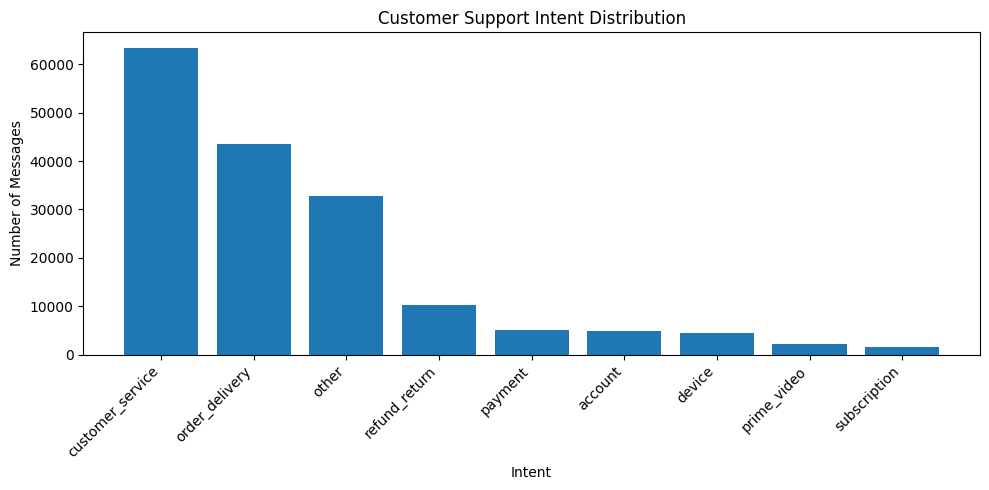

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    intent_distribution["intent"],
    intent_distribution["message_count"]
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Intent")
plt.ylabel("Number of Messages")
plt.title("Customer Support Intent Distribution")

plt.tight_layout()
plt.show()

In [35]:
data["intent"].value_counts()

,count
intent,
customer_service,63449
order_delivery,43585
other,32714
refund_return,10343
payment,5090
account,4862
device,4498
prime_video,2089
subscription,1543


In [36]:
# Look at messages that were not assigned an intent
other_messages = data[
    data["intent"] == "other"
]["customer_message"]

print("Number of other messages:", len(other_messages))

# Display 50 examples
for i, message in enumerate(other_messages.head(50), 1):
    print(f"{i}. {message}")

Number of other messages: 32714
1. amazonのfireTVstickが見れない😢
2. amazonプライムビデオ、再生エラーが多いです
3. @115825 also, beim Addams Family-Film in Prime sind Bild und Ton nicht wirklich synchron. Wie kommt's?
4. Thanks for the style advice, @115833 look ...I think? #Halloween2017 #flamingo https://t.co/XvI54La043
5. @115821, it’d be nice if the book I waited 4 months for wasn’t damaged inside of an undented box. #twinpeaks #twin… https://t.co/Lac4K7iQzJ https://t.co/JroqJKrH9Q
6. @115841 @115821 Feliz #Halloween2017 https://t.co/edHbRDnM8x
7. @115821  https://t.co/Gb0beuA3IN
8. @115821 please spend time &amp; money to fix your app. Constant issues with it.
9. @116316 Hi. How can I restrict results to German language books, while searching titles on amazon.de?
10. Rapidly losing faith in @115821 and their #esl CS ability to solve problems. No resolutions or follow ups.
11. @115830  website impossible to navigate - all I want to do is email about a faulty item - 20 min going round in circles. Infuriati

In [37]:
data[
    data["intent"] == "other"
][["customer_message", "support_response"]].head(20)

,customer_message,support_response
2,amazonのfireTVstickが見れない😢,@115770 こんにちは、アマゾン公式です。Fire TV Stickが見れないというのは、どのような状況でしょうか。一般的なトラブルシューティングを記載したヘルプがございますので、ご参照ください。https://t.co/2pbG55qJ7h ET
3,amazonプライムビデオ、再生エラーが多いです,@115792 ご不便をおかけしております。アプリをご利用でしょうか。強制停止&gt;端末の再起動にて改善する場合がございますので、お試しください。改善しない場合は、状況を確認しご案内させていただきますのでこちらからカスタマーサービスまでご連絡ください。https://t.co/NtNAX2Qh2u ET
8,"@115825 also, beim Addams Family-Film in Prime sind Bild und Ton nicht wirklich synchron. Wie kommt's?","@115824 Hi, wir erhalten die Filme/Serien so vom jeweiligen Studio. Gebe ich aber direkt als Feedback dorthin weiter. Gruß ^JS"
13,"Thanks for the style advice, @115833 look ...I think? #Halloween2017 #flamingo https://t.co/XvI54La043",@115832 Alexa says both styles are working for you! My vote goes to the Flamingo look! ^SE
24,"@115821, it’d be nice if the book I waited 4 months for wasn’t damaged inside of an undented box. #twinpeaks #twin… https://t.co/Lac4K7iQzJ https://t.co/JroqJKrH9Q",@115839 I'm sorry your book arrived this way! You can find replacement/refund options here: https://t.co/zRrkpVcaDF ^VS
25,@115841 @115821 Feliz #Halloween2017 https://t.co/edHbRDnM8x,@115840 ¡Que lindoooooooooo! 😍🐶🎃 ^JJ https://t.co/YSOVnjaPrO
32,@115821 https://t.co/Gb0beuA3IN,@115848 I'm sorry for the trouble this has caused you; please contact us so we may lend you a hand: https://t.co/hApLpMlfHN ^WM
60,@115821 please spend time &amp; money to fix your app. Constant issues with it.,"@116092 Oh no, Barton! Have you tried uninstalling and re-installing the app? Perhaps a power cycle too? Please let us know. ^KL"
75,"@116316 Hi. How can I restrict results to German language books, while searching titles on amazon.de?","@116315 Hi, just a question at the beginning - do you prefer answers in German or English? ^NW"
94,Rapidly losing faith in @115821 and their #esl CS ability to solve problems. No resolutions or follow ups.,"@116325 Sorry for the poor experience. Without giving any account information, could you tell us what's going on? We'd love top help! ^MH"


In [38]:
intent_categories = {
    "order_delivery": "Order tracking, delayed delivery, missing packages, shipping issues",

    "refund_return": "Refunds, returns, cancellations, money-back requests",

    "payment": "Payment, charges, billing, card/payment-method problems",

    "account": "Login, account access, account deletion, unauthorized account activity",

    "prime_video": "Prime Video playback, streaming, video/audio, content availability",

    "device": "Fire TV, Kindle, Alexa, Echo and device-related problems",

    "subscription": "Prime membership, subscription charges, membership cancellation",

    "product_issue": "Damaged, defective, broken, wrong or poor-quality products",

    "website_app": "Amazon website/app errors, navigation, checkout and technical issues",

    "product_search": "Searching for products, books, categories, availability or product information",

    "customer_service": "Complaints or requests specifically about Amazon support/agents",

    "other": "Messages that do not clearly belong to another category"
}

In [33]:
# Sample 100 messages from the dataset
sample = data["customer_message"].sample(
    n=100,
    random_state=42
)

for i, message in enumerate(sample, 1):
    print(f"{i}. {message}")

1. Well done not  @115830 13 months to deliver a book. No order updates, nothing. So long I forgot about the order and thought it was a mistake when it arrived Call that #service ?
2. @130293 ¿Pensáis arreglar los problemas de audio de Noragami Aragoto?Lleva mas de mes y medio con  el mismo problema.
3. @AmazonHelp I use Amazon France. Thank you for the info and at least thank you for replying!
4. @115821 can we talk about this please? Why is prime going up from £79 to £179?!?!?
5. Still waiting for @115850 to revert back. Been 5 dys since washing machine delivered. No demo yet. 3 phone calls, two live chats in vain
6. When @AmazonHelp deliver your parent’s Christmas present just a few days after ordering it, but write exactly what it is down the side of the box!! Not great when one of your parents takes delivery of it! Guess I’m on the hunt for a new gift... https://t.co/WcDwaUryx6
7. @115830 Why do you still send me plain text emails? Nowhere that I can see to update my email prefere

In [39]:
print("Total rows:", len(data))
print("Columns:", data.columns.tolist())

print("\nMissing values:")
print(data.isnull().sum())

print("\nDuplicate customer messages:")
print(data["customer_message"].duplicated().sum())

print("\nDuplicate conversation pairs:")
print(
    data.duplicated(
        subset=["customer_message", "support_response"]
    ).sum()
)

Total rows: 168173
Columns: ['customer_tweet_id', 'customer_id', 'customer_message', 'response_tweet_id', 'support_response', 'intent']

Missing values:
customer_tweet_id    0
customer_id          0
customer_message     0
response_tweet_id    0
support_response     0
intent               0
dtype: int64

Duplicate customer messages:
15645

Duplicate conversation pairs:
0


In [40]:
message_intent_check = (
    data.groupby("customer_message")["intent"]
    .nunique()
    .sort_values(ascending=False)
)

print("Messages associated with multiple intents:")
print((message_intent_check > 1).sum())

print("\nMaximum number of intents for one message:")
print(message_intent_check.max())

Messages associated with multiple intents:
0

Maximum number of intents for one message:
1


In [41]:
multi_intent_messages = message_intent_check[
    message_intent_check > 1
]

multi_intent_messages.head(20)

,intent
customer_message,


In [42]:
print(data["intent"].value_counts())

intent
customer_service    63449
order_delivery      43585
other               32714
refund_return       10343
payment              5090
account              4862
device               4498
prime_video          2089
subscription         1543
Name: count, dtype: int64


In [43]:
print(
    data["intent"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

intent
customer_service    37.73
order_delivery      25.92
other               19.45
refund_return        6.15
payment              3.03
account              2.89
device               2.67
prime_video          1.24
subscription         0.92
Name: proportion, dtype: float64


In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Get "other" messages
other_data = data[data["intent"] == "other"].copy()

print("Other messages:", len(other_data))

# TF-IDF
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5
)

X_other = vectorizer.fit_transform(
    other_data["customer_message"].astype(str)
)

print("TF-IDF shape:", X_other.shape)

Other messages: 32714
TF-IDF shape: (32714, 5000)


In [45]:
kmeans = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

other_data["cluster"] = kmeans.fit_predict(X_other)

print(other_data["cluster"].value_counts().sort_index())

cluster
0     2349
1     1293
2      285
3      266
4     4544
5     6151
6      368
7    12025
8      691
9     4742
Name: count, dtype: int64


In [46]:
terms = vectorizer.get_feature_names_out()

order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for cluster_num in range(10):
    top_terms = [
        terms[ind]
        for ind in order_centroids[cluster_num, :15]
    ]

    print("\n" + "=" * 60)
    print(f"CLUSTER {cluster_num}")
    print("=" * 60)
    print(", ".join(top_terms))


CLUSTER 0
120533, le, est, je, pas, et, pour, vous, colis, la, ai, en, que, https, merci

CLUSTER 1
https, 115850, delayed, amazon, día en, día que, día siguiente, días, días retraso, dónde, dónde puedo, eagerly, earlier, early, earphones

CLUSTER 2
amazon, https, amazon https, amazon prime, prime, 115850, book, tv, 116618, 10, una, non, mon, ありがとう, 115821

CLUSTER 3
116313, https, 120465, amazon, アマゾン, これは, 届いた, 118500, amp, 最悪, アマゾンさん, ﾟдﾟ, nintendo, 詐欺, cod

CLUSTER 4
115821, https, 115821 https, prime, just, amazon, box, time, thanks, hey 115821, packaging, don, really, hey, like

CLUSTER 5
115850, https, amazon, 115850 https, product, service, customer, price, 115851, india, sale, care, time, customers, buy

CLUSTER 6
gift, pay, amazon pay, 115850, balance, amazon, gift card, pay balance, card, money, cashback, diwali, add, diwali gift, amazon gift

CLUSTER 7
115830, https, amazon, 116316, prime, ich, nicht, die, 116618, 120540, ist, das, di, 115825, app

CLUSTER 8
119625, season

In [47]:
for cluster_num in range(10):

    print("\n" + "#" * 70)
    print(f"CLUSTER {cluster_num}")
    print("#" * 70)

    examples = other_data[
        other_data["cluster"] == cluster_num
    ]["customer_message"].head(10)

    for i, message in enumerate(examples, 1):
        print(f"{i}. {message}")


######################################################################
CLUSTER 0
######################################################################
1. @120533 @120534 J'ai demandé le remboursement @120533
Coucou @120535 plus la peine de vous pointer (si un jour vous pensiez vraiment livrer)
2. Bon @120533 et @120534  on fait quoi?
Livre precommandé le 30/09 pour l'avoir le jour de la sortie.... moralité : https://t.co/HGTFhesA8K
3. Bonjour @120533 ! C’est fâcheux de prendre La Poste pour les livraisons expresses la veille des jours fériés... https://t.co/aULnltgh5W
4. @115821 après un chat direct avec vous au sujet d'une commande ne venant pas de moi, vous avez tout de même débité mon compte de 110,94€. ??
5. Par contre @120533 , vous allez très vite me rembourser mes colis NON LIVRABLES parce que vous ne savez pas effectué le tri correctement.
6. Sympa le livre mal découpé @120533 😂
Les produits sont parfaits d'habitude alors je vous pardonne https://t.co/DKsn618fo7
7. C’est quoi

In [48]:
import re
import html

def clean_for_intent(text):
    text = str(text)

    # Decode HTML entities
    text = html.unescape(text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove @mentions
    text = re.sub(r"@\w+", " ", text)

    # Remove hashtags symbol but keep the word
    text = re.sub(r"#", "", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text.lower()


data["intent_text"] = data["customer_message"].apply(clean_for_intent)

data[["customer_message", "intent_text"]].head(20)

,customer_message,intent_text
0,@AmazonHelp 電話で対応してもらいましたが改良されませんでした。\n保証期間も過ぎてるので買い直しになるんでしょうね。,電話で対応してもらいましたが改良されませんでした。 保証期間も過ぎてるので買い直しになるんでしょうね。
1,@AmazonHelp こちらこそありがとうございました。,こちらこそありがとうございました。
2,amazonのfireTVstickが見れない😢,amazonのfiretvstickが見れない😢
3,amazonプライムビデオ、再生エラーが多いです,amazonプライムビデオ、再生エラーが多いです
4,"@AmazonHelp 3 different people have given 3 different answers and I still don't have my order. Says delivered Saturday, was not, I was home all day","3 different people have given 3 different answers and i still don't have my order. says delivered saturday, was not, i was home all day"
5,Way to drop the ball on customer service @115821 so pissed right now!,way to drop the ball on customer service so pissed right now!
6,@115823 I want my amazon payments account CLOSED. dm me please.,i want my amazon payments account closed. dm me please.
7,"@AmazonHelp Okay, danke für die Info","okay, danke für die info"
8,"@115825 also, beim Addams Family-Film in Prime sind Bild und Ton nicht wirklich synchron. Wie kommt's?","also, beim addams family-film in prime sind bild und ton nicht wirklich synchron. wie kommt's?"
9,@AmazonHelp @115826 Yeah this is crazy we’re less than a week away and still no Shipping Information on something that we Pre-ordered back in August,yeah this is crazy we’re less than a week away and still no shipping information on something that we pre-ordered back in august


In [49]:
other_clean = data[
    data["intent"] == "other"
][["customer_message", "intent_text"]]

for i, row in other_clean.head(30).iterrows():
    print("ORIGINAL :", row["customer_message"])
    print("CLEANED  :", row["intent_text"])
    print("-" * 80)

ORIGINAL : amazonのfireTVstickが見れない😢
CLEANED  : amazonのfiretvstickが見れない😢
--------------------------------------------------------------------------------
ORIGINAL : amazonプライムビデオ、再生エラーが多いです
CLEANED  : amazonプライムビデオ、再生エラーが多いです
--------------------------------------------------------------------------------
ORIGINAL : @115825 also, beim Addams Family-Film in Prime sind Bild und Ton nicht wirklich synchron. Wie kommt's?
CLEANED  : also, beim addams family-film in prime sind bild und ton nicht wirklich synchron. wie kommt's?
--------------------------------------------------------------------------------
ORIGINAL : Thanks for the style advice, @115833 look ...I think? #Halloween2017 #flamingo https://t.co/XvI54La043
CLEANED  : thanks for the style advice, look ...i think? halloween2017 flamingo
--------------------------------------------------------------------------------
ORIGINAL : @115821, it’d be nice if the book I waited 4 months for wasn’t damaged inside of an undented box. #twinpeak

In [51]:
support_words = [
    "order", "delivery", "delivered", "shipping", "package",
    "refund", "return", "payment", "charge", "charged",
    "account", "login", "password", "prime", "video",
    "device", "fire", "kindle", "alexa", "subscription",
    "membership", "customer", "support", "help",
    "amazon", "app", "website", "checkout", "product",
    "book", "seller", "cancel", "broken", "damaged",
    "wrong", "missing", "tracking"
]

def has_support_context(text):
    text = str(text).lower()
    return any(word in text for word in support_words)


data["support_context"] = data["intent_text"].apply(has_support_context)

print(
    data["support_context"].value_counts()
)

support_context
True     106109
False     62064
Name: count, dtype: int64


In [52]:
possible_non_support = data[
    (data["intent"] == "other") &
    (data["support_context"] == False)
]

print("Possible non-support messages:", len(possible_non_support))

for message in possible_non_support["customer_message"].head(50):
    print("-", message)

Possible non-support messages: 17579
- Thanks for the style advice, @115833 look ...I think? #Halloween2017 #flamingo https://t.co/XvI54La043
- @115841 @115821 Feliz #Halloween2017 https://t.co/edHbRDnM8x
- @115821  https://t.co/Gb0beuA3IN
- Rapidly losing faith in @115821 and their #esl CS ability to solve problems. No resolutions or follow ups.
- @116313 注文した覚えのないものが届きました。
家族も誰も何もしていません。
勝手にレビューも書いてたり、ギフト券も購入してる様子。
今パニック状態なのですが、どこに連絡すればよいのでしょうか？
- @116875 ¿como puedo trackear si esta próximo a ser entregado un paquete que tiene fecha de hoy? Gracias
- @115850 का एकाउंट परमानेंटली डिलीट कैसे करते है?
- Jamas volvere a comprar en @116875 :'v
- I lost my signal while searching something in @115821 and since the page didn't load, this shows up...I am not even mad. #DogsForLife https://t.co/QhdOmksrrY
- @115821 Hasta que al fin llegó #BrBa https://t.co/7y2HKQlA2R
- @115850 pls investigate ur satara (Maharashtra) amzn staff or ur reputation is doomed in the region in long term.
- Not here 

In [53]:
intent_patterns = {

    "order_delivery": [
        r"\bwhere.*(order|package|parcel|delivery|book|item)\b",
        r"\b(package|parcel|order).*(late|delay|delayed|missing|lost|arrive|arrived|deliver)\b",
        r"\b(deliver|delivery).*(late|delay|today|tomorrow|missing)\b",
        r"\bmarked as delivered\b",
        r"\bdelivered.*not received\b",
        r"\bnot.*received\b",
        r"\bshipping\b",
        r"\btracking\b",
        r"\bdispatch\b",
        r"\bcarrier\b",
        r"\bdelivery date\b",
        r"\bdelivery.*problem\b"
    ],

    "refund_return": [
        r"\brefund\b",
        r"\brefunded\b",
        r"\breturn\b",
        r"\breturned\b",
        r"\bmoney back\b",
        r"\breimburse\b",
        r"\bcharge.*back\b"
    ],

    "payment": [
        r"\bpayment\b",
        r"\bpaid\b",
        r"\bcharge\b",
        r"\bcharged\b",
        r"\bbilling\b",
        r"\bcredit card\b",
        r"\bdebit card\b",
        r"\bpayment method\b",
        r"\bcharged twice\b"
    ],

    "account": [
        r"\baccount\b",
        r"\blogin\b",
        r"\bsign in\b",
        r"\bpassword\b",
        r"\bdelete.*account\b",
        r"\baccount.*delete\b",
        r"\bunauthorized\b",
        r"\bdidn't order\b",
        r"\bdid not order\b",
        r"\bdon't recognize\b",
        r"\bdidn't make\b",
        r"\bscam\b",
        r"\bfraud\b"
    ],

    "prime_video": [
        r"\bprime video\b",
        r"\bwatching\b",
        r"\bwatch\b",
        r"\bstream\b",
        r"\bstreaming\b",
        r"\bplayback\b",
        r"\bbuffering\b",
        r"\bfreezing\b",
        r"\bepisode\b",
        r"\bseason\b",
        r"\bmovie\b",
        r"\bvideo\b"
    ],

    "device": [
        r"\bfire tv\b",
        r"\bfirestick\b",
        r"\bkindle\b",
        r"\balexa\b",
        r"\becho\b",
        r"\bdevice\b"
    ],

    "subscription": [
        r"\bprime membership\b",
        r"\bprime member\b",
        r"\bmembership\b",
        r"\bsubscription\b",
        r"\bsubscribe\b",
        r"\brenew\b",
        r"\brenewed\b",
        r"\bautomatically.*renew\b",
        r"\bcancel.*prime\b"
    ],

    "product_issue": [
        r"\bdamaged\b",
        r"\bdamage\b",
        r"\bbroken\b",
        r"\bdefective\b",
        r"\bwrong item\b",
        r"\bwrong product\b",
        r"\bpoor packaging\b",
        r"\bbent\b",
        r"\bmissing parts\b"
    ],

    "website_app": [
        r"\bwebsite\b",
        r"\bapp\b",
        r"\bpage.*not load\b",
        r"\bpage.*didn't load\b",
        r"\bcheckout\b",
        r"\berror\b",
        r"\bbug\b",
        r"\bsafari\b",
        r"\blogged\b",
        r"\bnavigation\b"
    ],

    "product_search": [
        r"\blooking for\b",
        r"\bsearch.*product\b",
        r"\bsearch.*book\b",
        r"\bfind.*book\b",
        r"\brestock\b",
        r"\bavailable\b",
        r"\bavailability\b",
        r"\bin stock\b"
    ],

    "customer_service": [
        r"\bcustomer service\b",
        r"\bcustomer support\b",
        r"\bsupport\b",
        r"\bagent\b",
        r"\brepresentative\b",
        r"\bsupervisor\b",
        r"\bcall.*support\b",
        r"\bcontact.*support\b",
        r"\bhelp.*support\b"
    ]
}

In [54]:
import re

def classify_intent(text):
    text = str(text).lower()

    priority = [
        "refund_return",
        "payment",
        "account",
        "subscription",
        "prime_video",
        "device",
        "website_app",
        "product_issue",
        "product_search",
        "order_delivery",
        "customer_service"
    ]

    for intent in priority:
        for pattern in intent_patterns[intent]:
            if re.search(pattern, text):
                return intent

    return "unclassified"

In [55]:
data["new_intent"] = data["intent_text"].apply(classify_intent)

print(data["new_intent"].value_counts())

new_intent
unclassified        113533
order_delivery       14226
refund_return         9777
account               5807
customer_service      4736
payment               4222
website_app           3962
device                3786
subscription          2476
prime_video           2383
product_issue         1723
product_search        1542
Name: count, dtype: int64


In [56]:
data["new_intent"].value_counts()

,count
new_intent,
unclassified,113533
order_delivery,14226
refund_return,9777
account,5807
customer_service,4736
payment,4222
website_app,3962
device,3786
subscription,2476


In [57]:
print("Unique customer messages:", data["customer_message"].nunique())
print("Unique support responses:", data["support_response"].nunique())

Unique customer messages: 152528
Unique support responses: 168140


In [58]:
response_counts = (
    data["support_response"]
    .value_counts()
    .head(30)
)

response_counts

,count
support_response,
@140964 Please don't provide your order details as we consider it personal information. Our twitter page is visible to public. ^SQ,3
@374403 Please don't provide your order details as we consider it personal information. Our twitter page is visible to public. ^SQ,3
@150316 Only the available promotions on the order page will be considered eligible for the product. ^MJ,2
@427333 Glad to know that you're interested in purchasing the iPhone X. You may get the notification here: https://t.co/MpS9vddKPl ^NS,2
"@200264 Please don't provide your order details, as we consider it to be personal information. Our Twitter page is public.​ ^RW",2
"@337086 Please don't provide your order details, we consider it personal information. Our Twitter page is visible to public. ^HA",2
"@158923 Please don't provide your order details, as we consider it to be personal information. Our Twitter page is public.​ ^MM",2
@338159 Please don't provide your order details as we consider it personal info. Our twitter page is visible to public.(2/2) ^CB,2
@722953 We’d like to help you. Please share your details here: https://t.co/beaaDm0muc and we’ll contact you soon. ^JS,2


In [59]:
data[["customer_message", "support_response"]].sample(
    20,
    random_state=42
)

,customer_message,support_response
152960,"Well done not @115830 13 months to deliver a book. No order updates, nothing. So long I forgot about the order and thought it was a mistake when it arrived Call that #service ?","@768986 Not all orders are available to ship right away. We do our best to provide you with an accurate delivery estimate at checkout, but in some cases you'll be sent an e-mail when we have a mor..."
97111,@130293 ¿Pensáis arreglar los problemas de audio de Noragami Aragoto?Lleva mas de mes y medio con el mismo problema.,"@198159 Hola, lamento el inconveniente. ¿Lo has reportado con Servicio al Cliente? ^KS"
22589,@AmazonHelp I use Amazon France. Thank you for the info and at least thank you for replying!,@191864 How can i help you ? ^SN
56128,@115821 can we talk about this please? Why is prime going up from £79 to £179?!?!?,"@308745 Hi there! The Amazon Prime Membership is £7.99 per month, or £79 per year. You can learn more here: https://t.co/JO5vtq2LZP. ^WJ"
79893,"Still waiting for @115850 to revert back. Been 5 dys since washing machine delivered. No demo yet. 3 phone calls, two live chats in vain",@399638 I'm sorry that the demo for the product hasn't been done yet. We'd like to look into it. Kindly share your details 1/2 ^AP
158931,"When @AmazonHelp deliver your parent’s Christmas present just a few days after ordering it, but write exactly what it is down the side of the box!! Not great when one of your parents takes deliver...",@140073 Oh no! Looks like this may have been delivered using out Frustration Free Packaging. You can find out more about that here: https://t.co/RTIHGOgWr4 ^TR
57308,@115830 Why do you still send me plain text emails? Nowhere that I can see to update my email preferences to html #StuckInThe90s,@313371 You may update your preferences under General Settings here: https://t.co/TiSl7GfMmj I hope this helps! ^RA
32579,"I just joined Prime. The very first delivery guy spoke rudely, claimed to not have been given my address, hung up on me. @115850","@164241 Sorry for the unpleasant experience. Believe me, this isn't the kind of service we would want our customers (1/3) ^KA"
27480,What’s the point in showing me places that I can’t get one-day pick-up at under the “free one-day pickup” link? @115821,@152471 I understand your frustration. Please send us feedback via e-mail here: https://t.co/hApLpMlfHN following this sequence:\n\n1. Prime and Something else\n2. More non-order questions&gt; Giv...
129781,@AmazonHelp I've clicked on my recent orders but it's blank ... How can I get a refund?,"@667443 Let's look into this together! When you have the chance, please reach out to us here: https://t.co/JzP7hlA23B. ^HC"


In [60]:
import re
import html

def clean_text(text):
    text = str(text)
    text = html.unescape(text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove Twitter mentions
    text = re.sub(r"@\w+", " ", text)

    # Remove hashtags but keep the word
    text = re.sub(r"#", "", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text.lower()

data["clean_customer_message"] = (
    data["customer_message"]
    .apply(clean_text)
)

In [61]:
data[
    ["customer_message", "clean_customer_message"]
].sample(10, random_state=42)

,customer_message,clean_customer_message
152960,"Well done not @115830 13 months to deliver a book. No order updates, nothing. So long I forgot about the order and thought it was a mistake when it arrived Call that #service ?","well done not 13 months to deliver a book. no order updates, nothing. so long i forgot about the order and thought it was a mistake when it arrived call that service ?"
97111,@130293 ¿Pensáis arreglar los problemas de audio de Noragami Aragoto?Lleva mas de mes y medio con el mismo problema.,¿pensáis arreglar los problemas de audio de noragami aragoto?lleva mas de mes y medio con el mismo problema.
22589,@AmazonHelp I use Amazon France. Thank you for the info and at least thank you for replying!,i use amazon france. thank you for the info and at least thank you for replying!
56128,@115821 can we talk about this please? Why is prime going up from £79 to £179?!?!?,can we talk about this please? why is prime going up from £79 to £179?!?!?
79893,"Still waiting for @115850 to revert back. Been 5 dys since washing machine delivered. No demo yet. 3 phone calls, two live chats in vain","still waiting for to revert back. been 5 dys since washing machine delivered. no demo yet. 3 phone calls, two live chats in vain"
158931,"When @AmazonHelp deliver your parent’s Christmas present just a few days after ordering it, but write exactly what it is down the side of the box!! Not great when one of your parents takes deliver...","when deliver your parent’s christmas present just a few days after ordering it, but write exactly what it is down the side of the box!! not great when one of your parents takes delivery of it! gue..."
57308,@115830 Why do you still send me plain text emails? Nowhere that I can see to update my email preferences to html #StuckInThe90s,why do you still send me plain text emails? nowhere that i can see to update my email preferences to html stuckinthe90s
32579,"I just joined Prime. The very first delivery guy spoke rudely, claimed to not have been given my address, hung up on me. @115850","i just joined prime. the very first delivery guy spoke rudely, claimed to not have been given my address, hung up on me."
27480,What’s the point in showing me places that I can’t get one-day pick-up at under the “free one-day pickup” link? @115821,what’s the point in showing me places that i can’t get one-day pick-up at under the “free one-day pickup” link?
129781,@AmazonHelp I've clicked on my recent orders but it's blank ... How can I get a refund?,i've clicked on my recent orders but it's blank ... how can i get a refund?


In [62]:
from sklearn.model_selection import train_test_split

unique_messages = data["clean_customer_message"].drop_duplicates()

train_messages, test_messages = train_test_split(
    unique_messages,
    test_size=0.20,
    random_state=42
)

train_data = data[
    data["clean_customer_message"].isin(train_messages)
].copy()

test_data = data[
    data["clean_customer_message"].isin(test_messages)
].copy()

print("Train rows:", len(train_data))
print("Test rows:", len(test_data))
print("Train unique messages:", train_data["clean_customer_message"].nunique())
print("Test unique messages:", test_data["clean_customer_message"].nunique())

Train rows: 134770
Test rows: 33403
Train unique messages: 120502
Test unique messages: 30126


In [63]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=100000
)

X_train = tfidf.fit_transform(
    train_data["clean_customer_message"]
)

X_test = tfidf.transform(
    test_data["clean_customer_message"]
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (134770, 100000)
X_test shape: (33403, 100000)


In [64]:
from sklearn.metrics.pairwise import cosine_similarity

def retrieve_response(query, top_k=3):

    query_clean = clean_text(query)

    query_vector = tfidf.transform([query_clean])

    similarities = cosine_similarity(
        query_vector,
        X_train
    ).flatten()

    top_indices = similarities.argsort()[-top_k:][::-1]

    results = train_data.iloc[top_indices].copy()

    results["similarity"] = similarities[top_indices]

    return results[
        [
            "customer_message",
            "support_response",
            "similarity"
        ]
    ]

In [65]:
queries = [
    "My package has not arrived yet",
    "I was charged for Prime unexpectedly",
    "My Prime Video keeps buffering",
    "I want to return my order",
    "Someone placed an order on my account"
]

for query in queries:
    print("\n" + "="*80)
    print("QUERY:", query)
    print("="*80)

    print(
        retrieve_response(query, top_k=3).to_string(index=False)
    )


QUERY: My package has not arrived yet
                                                                                                      customer_message                                                                                                                                                                                    support_response  similarity
                                       @AmazonHelp Hey so my package has not arrived yet. Can I get this sorted please @119403 While we can't access order or account details through social media, we'd still like to help! Please reach us directly via phone or chat so we can investigate: https://t.co/JzP7hlA23B ^CS      0.5951
Hey @115850 , my package has not arrived yet @AmazonHelp  but ur tracking shows tat it shld have been delivered by now                                                                 @340085 Please don't provide your order details, we consider it personal information. Our Twitter page is visible to public.

In [66]:
!pip install -q sentence-transformers

In [3]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "paraphrase-multilingual-MiniLM-L12-v2"
)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [67]:
train_texts = train_data["clean_customer_message"].tolist()

train_embeddings = embedding_model.encode(
    train_texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

print(train_embeddings.shape)

Batches:   0%|          | 0/2106 [00:00<?, ?it/s]

(134770, 384)


In [68]:
import numpy as np

def semantic_retrieve_response(query, top_k=3):

    query_clean = clean_text(query)

    query_embedding = embedding_model.encode(
        [query_clean],
        normalize_embeddings=True
    )

    similarities = np.dot(
        train_embeddings,
        query_embedding[0]
    )

    top_indices = np.argsort(similarities)[-top_k:][::-1]

    results = train_data.iloc[top_indices].copy()

    results["similarity"] = similarities[top_indices]

    return results[
        [
            "customer_message",
            "support_response",
            "similarity"
        ]
    ]

In [69]:
queries = [
    "My package has not arrived yet",
    "I was charged for Prime unexpectedly",
    "My Prime Video keeps buffering",
    "I want to return my order",
    "Someone placed an order on my account"
]

for query in queries:

    print("\n" + "=" * 80)
    print("QUERY:", query)
    print("=" * 80)

    print(
        semantic_retrieve_response(
            query,
            top_k=3
        ).to_string(index=False)
    )


QUERY: My package has not arrived yet
                                                         customer_message                                                                                                                   support_response  similarity
                                   @AmazonHelp My package is not here yet      @125005 Carriers have until 8 PM to deliver orders. Have we missed the delivery date shown here: https://t.co/Y5jpI9gRhE? ^VS    0.947152
                                 My package haven’t came yet ☹️☹️ @115821                                              @236407 Hi there! Deliveries are made until 8 PM. Keep us updated on its arrival! ^AB    0.914227
Hey @AmazonHelp why hasn't my package arrived yet https://t.co/vCna6aLgfP @197802 Thanks for reaching out! So sorry you haven't received your yarn! Have you received any e-mails from us about a delay? ^KJ    0.899495

QUERY: I was charged for Prime unexpectedly
                                                

In [70]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def evaluate_retrieval(test_data, train_data, train_embeddings, k=5):

    correct = 0
    total = len(test_data)

    for idx, row in enumerate(test_data.itertuples()):

        query_embedding = embedding_model.encode(
            [row.clean_customer_message],
            normalize_embeddings=True
        )

        similarities = np.dot(
            train_embeddings,
            query_embedding[0]
        )

        top_indices = np.argsort(similarities)[-k:][::-1]

        retrieved_responses = train_data.iloc[
            top_indices
        ]["support_response"].values

        if row.support_response in retrieved_responses:
            correct += 1

        if (idx + 1) % 1000 == 0:
            print(f"Processed {idx + 1}/{total}")

    return correct / total

In [71]:
recall_at_5 = evaluate_retrieval(
    test_data,
    train_data,
    train_embeddings,
    k=5
)

print("Recall@5:", recall_at_5)

Processed 1000/33403
Processed 2000/33403
Processed 3000/33403
Processed 4000/33403
Processed 5000/33403
Processed 6000/33403
Processed 7000/33403
Processed 8000/33403
Processed 9000/33403
Processed 10000/33403
Processed 11000/33403
Processed 12000/33403
Processed 13000/33403
Processed 14000/33403
Processed 15000/33403
Processed 16000/33403
Processed 17000/33403
Processed 18000/33403
Processed 19000/33403
Processed 20000/33403
Processed 21000/33403
Processed 22000/33403
Processed 23000/33403
Processed 24000/33403
Processed 25000/33403
Processed 26000/33403
Processed 27000/33403
Processed 28000/33403
Processed 29000/33403
Processed 30000/33403
Processed 31000/33403
Processed 32000/33403
Processed 33000/33403
Recall@5: 2.9937430769691346e-05


In [72]:
print("Test rows:", len(test_data))
print("Test unique customer messages:", test_data["clean_customer_message"].nunique())

print(
    "Test messages also appearing in train:",
    test_data["clean_customer_message"].isin(
        train_data["clean_customer_message"]
    ).sum()
)

Test rows: 33403
Test unique customer messages: 30126
Test messages also appearing in train: 0


In [73]:
sample_test = test_data.sample(
    100,
    random_state=42
).reset_index(drop=True)

sample_embeddings = embedding_model.encode(
    sample_test["clean_customer_message"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

similarity_scores = []

for i in range(len(sample_test)):

    similarities = np.dot(
        train_embeddings,
        sample_embeddings[i]
    )

    best_score = similarities.max()

    similarity_scores.append(best_score)

print("Average top-1 similarity:",
      np.mean(similarity_scores))

print("Median top-1 similarity:",
      np.median(similarity_scores))

print("Minimum top-1 similarity:",
      np.min(similarity_scores))

print("Maximum top-1 similarity:",
      np.max(similarity_scores))


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Average top-1 similarity: 0.7576563
Median top-1 similarity: 0.76813805
Minimum top-1 similarity: 0.5223644
Maximum top-1 similarity: 0.9427422


In [74]:
sample_test["top_similarity"] = similarity_scores

sample_test[
    ["customer_message", "top_similarity"]
].sort_values(
    "top_similarity"
).head(10)

,customer_message,top_similarity
70,I need to ask a stupid question about the @115821 Fire HD Tablets and I'm really not interested in being judged. Where are my benevolent techie people &amp; Blerds?,0.522364
79,2017: the year I fell in love with @115821,0.551239
44,@115850 Please verify your offers. The advertisement says that for a minimum cart value of nivea products should be 200 or more but your steps says it has to reach minimum of 299. https://t.co/qok...,0.571810
50,@115850 How come the prce of Sandisk microsd crd wth adaptor priced in ur 'Lightning Deal' as 649 bcomes 739 at chkout wth normal delivery,0.572686
94,@AmazonHelp And which on of these do you think has applied to a sweeping brush being delivered to an apartment block with a 24/7 concierge?,0.585388
96,Yo @115830 I'm not even mad that your guy made up the 'safe place I told you about'. This was great fun. https://t.co/7ef5QwAu94,0.591427
53,@115850 Hello. Where to complain guys? I am facing a problem since 30days. please help,0.606184
82,@115821 what the hells wrong with the UFC app on the fire stick!? I ordered the fight and it says my order was submitted and it's not loadin,0.613899
9,@AmazonHelp Don’t think they can do much! It’s an electrical item. One came in no working condition and the other just stopped working randomly.,0.635397
17,@115850 why does my order have to stay in Bangalore for 24h?\nI usually get my orders ~4-6 days.\nThis one ships from Chennai..and still after 4 days it's only in bangalore,0.635951


In [75]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def hybrid_retrieve_response(
    query,
    top_k=3,
    semantic_weight=0.7,
    tfidf_weight=0.3
):

    query_clean = clean_text(query)

    # -----------------------------
    # 1. TF-IDF similarity
    # -----------------------------
    query_tfidf = tfidf.transform([query_clean])

    tfidf_scores = cosine_similarity(
        query_tfidf,
        X_train
    ).flatten()

    # -----------------------------
    # 2. Semantic similarity
    # -----------------------------
    query_embedding = embedding_model.encode(
        [query_clean],
        normalize_embeddings=True
    )

    semantic_scores = np.dot(
        train_embeddings,
        query_embedding[0]
    )

    # -----------------------------
    # 3. Combine scores
    # -----------------------------
    hybrid_scores = (
        semantic_weight * semantic_scores
        +
        tfidf_weight * tfidf_scores
    )

    top_indices = np.argsort(
        hybrid_scores
    )[-top_k:][::-1]

    results = train_data.iloc[
        top_indices
    ].copy()

    results["semantic_score"] = semantic_scores[top_indices]
    results["tfidf_score"] = tfidf_scores[top_indices]
    results["hybrid_score"] = hybrid_scores[top_indices]

    return results[
        [
            "customer_message",
            "support_response",
            "semantic_score",
            "tfidf_score",
            "hybrid_score"
        ]
    ]

In [76]:
queries = [
    "My package has not arrived yet",
    "I was charged for Prime unexpectedly",
    "My Prime Video keeps buffering",
    "I want to return my order",
    "Someone placed an order on my account"
]

for query in queries:

    print("\n" + "=" * 100)
    print("QUERY:", query)
    print("=" * 100)

    print(
        hybrid_retrieve_response(
            query,
            top_k=3
        ).to_string(index=False)
    )


QUERY: My package has not arrived yet
                                                                   customer_message                                                                                                                                                          support_response  semantic_score  tfidf_score  hybrid_score
          Hey @AmazonHelp why hasn't my package arrived yet https://t.co/vCna6aLgfP                                        @197802 Thanks for reaching out! So sorry you haven't received your yarn! Have you received any e-mails from us about a delay? ^KJ        0.899495     0.389023      0.746353
                                             @AmazonHelp My package is not here yet                                             @125005 Carriers have until 8 PM to deliver orders. Have we missed the delivery date shown here: https://t.co/Y5jpI9gRhE? ^VS        0.947152     0.235336      0.733607
@AmazonHelp it’s now after 9 PM and package has not arrived https://t.

In [77]:
import numpy as np

# Take 100 random test messages
eval_sample = test_data.sample(
    100,
    random_state=42
).reset_index(drop=True)

# Encode all evaluation queries at once
eval_embeddings = embedding_model.encode(
    eval_sample["clean_customer_message"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

semantic_top_scores = []
tfidf_top_scores = []
hybrid_top_scores = []

for i in range(len(eval_sample)):

    # -------------------------
    # Semantic similarity
    # -------------------------
    semantic_scores = np.dot(
        train_embeddings,
        eval_embeddings[i]
    )

    semantic_best = semantic_scores.max()

    # -------------------------
    # TF-IDF similarity
    # -------------------------
    query_tfidf = tfidf.transform(
        [eval_sample.loc[i, "clean_customer_message"]]
    )

    tfidf_scores = cosine_similarity(
        query_tfidf,
        X_train
    ).flatten()

    tfidf_best = tfidf_scores.max()

    # -------------------------
    # Hybrid similarity
    # -------------------------
    hybrid_scores = (
        0.7 * semantic_scores
        +
        0.3 * tfidf_scores
    )

    hybrid_best = hybrid_scores.max()

    semantic_top_scores.append(semantic_best)
    tfidf_top_scores.append(tfidf_best)
    hybrid_top_scores.append(hybrid_best)


print("===== RETRIEVAL COMPARISON =====")

print(
    "Semantic average:",
    np.mean(semantic_top_scores)
)

print(
    "TF-IDF average:",
    np.mean(tfidf_top_scores)
)

print(
    "Hybrid average:",
    np.mean(hybrid_top_scores)
)

print()

print(
    "Semantic median:",
    np.median(semantic_top_scores)
)

print(
    "TF-IDF median:",
    np.median(tfidf_top_scores)
)

print(
    "Hybrid median:",
    np.median(hybrid_top_scores)
)

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

===== RETRIEVAL COMPARISON =====
Semantic average: 0.7576563
TF-IDF average: 0.3601136935945057
Hybrid average: 0.582074998111528

Semantic median: 0.76813805
TF-IDF median: 0.33722011998563306
Hybrid median: 0.5738638169922001


In [78]:
def hybrid_retrieve_with_confidence(
    query,
    top_k=3
):
    query_clean = clean_text(query)

    # TF-IDF
    query_tfidf = tfidf.transform([query_clean])

    tfidf_scores = cosine_similarity(
        query_tfidf,
        X_train
    ).flatten()

    # Semantic
    query_embedding = embedding_model.encode(
        [query_clean],
        normalize_embeddings=True
    )

    semantic_scores = np.dot(
        train_embeddings,
        query_embedding[0]
    )

    # Hybrid
    hybrid_scores = (
        0.7 * semantic_scores
        +
        0.3 * tfidf_scores
    )

    # Top results
    top_indices = np.argsort(
        hybrid_scores
    )[-top_k:][::-1]

    results = train_data.iloc[
        top_indices
    ].copy()

    results["semantic_score"] = semantic_scores[top_indices]
    results["tfidf_score"] = tfidf_scores[top_indices]
    results["hybrid_score"] = hybrid_scores[top_indices]

    best_score = hybrid_scores[top_indices[0]]

    # Simple confidence levels for now
    if best_score >= 0.70:
        confidence = "High"
    elif best_score >= 0.55:
        confidence = "Medium"
    else:
        confidence = "Low"

    return results[
        [
            "customer_message",
            "support_response",
            "semantic_score",
            "tfidf_score",
            "hybrid_score"
        ]
    ], confidence

In [79]:
queries = [
    "My package has not arrived yet",
    "I was charged for Prime unexpectedly",
    "My Prime Video keeps buffering",
    "I want to return my order",
    "Someone placed an order on my account",
    "asdfgh random completely unrelated sentence"
]

for query in queries:

    results, confidence = hybrid_retrieve_with_confidence(
        query,
        top_k=3
    )

    print("\n" + "=" * 100)
    print("QUERY:", query)
    print("CONFIDENCE:", confidence)
    print("=" * 100)

    print(
        results.to_string(index=False)
    )


QUERY: My package has not arrived yet
CONFIDENCE: High
                                                                   customer_message                                                                                                                                                          support_response  semantic_score  tfidf_score  hybrid_score
          Hey @AmazonHelp why hasn't my package arrived yet https://t.co/vCna6aLgfP                                        @197802 Thanks for reaching out! So sorry you haven't received your yarn! Have you received any e-mails from us about a delay? ^KJ        0.899495     0.389023      0.746353
                                             @AmazonHelp My package is not here yet                                             @125005 Carriers have until 8 PM to deliver orders. Have we missed the delivery date shown here: https://t.co/Y5jpI9gRhE? ^VS        0.947152     0.235336      0.733607
@AmazonHelp it’s now after 9 PM and package has not a

In [80]:
# Show 20 random test queries
evaluation_examples = test_data[
    [
        "customer_message",
        "support_response"
    ]
].sample(
    20,
    random_state=100
).reset_index(drop=True)

evaluation_examples

,customer_message,support_response
0,@115821 truly just pissed me off.,"@249062 Hi! Maybe we can help. Can you explain in detail, without giving sensitive information, what happened? Let us know! ^DA"
1,"Awful service from @115830 Order not fulfilled, no explaination as to why. Seriously wondering if Prime is worth the money.",@454546 We aim to meet the delivery date provided in your order confirmation e-mail: https://t.co/YnHxGSmFO2 Has the date passed? ^KJ
2,@AmazonHelp Horrible experience... Amazon is si dumb and naive... They have been repeating the same thing... Is there anything that you guys care for,@406982 Could you confirm receiving an email from our team? (2/2) ^KA
3,@115850 Is there any way by which I can order Redmi 4A 32 GB @138673 ? Have been trying your lightning deal for one month and sadly I am not able to make it to even the waitlist. Leave alone the p...,"@280277 Due to overwhelming response &amp; limited stock, orders are fulfilled on a first-come-first-serve basis. Since this phone is being sold in a flash sale model, we cannot guarantee the avai..."
4,"Huhu @AmazonHelp! Früher gab es mal eine 30-Tage-Test-Garantie ... sollte man in dieser Zeit unzufrieden mit dem Tablet sein, konnte man es kostenfrei zurückschicken und Geld wurde erstattet. Ist ...",@287913 Du kannst jeden Artikel innerhalb von 30 Tagen zurückschicken. Alle Informationen zur Rückgabe findest du hier: https://t.co/RSotcasuGJ Liebe Grüße ^TA
5,"@AmazonHelp I am very well aware that i can return the item, I am so embarrased as this was supposed to be a bday present and dis has costed me more.",@219966 I really understand your concern. Certainly did not expect this to happen. I've noted your feedback and will be sure to pass on your feedback to the concerned department. ^JS
6,@AmazonHelp There is no option to contact to customer service on your website,"@445667 I get your concern, Sam. Please use the link shared above to reach us. We'll help you to resolve your concern. ^SV"
7,Livraison re-planifiée à la demande du client c'est faux hein. Le transporteur a décidé ça tout seul et moi j'attends! @120533 @AmazonHelp,"@524867 Bonjour, vous m'en voyez navrée. De quel transporteur s'agit-il s'il vous plaît?"
8,"@115821 You got the best delivery in the world ? Cool story bro, I'm still waiting my Ethernet Wires, it's been 2 weeks and they were already delayed twice.\nWhat I am suppose to do ? Subscribe to...","@761043 Hello,\nIs the item shipped by Amazon or by a seller.\n^MD"
9,@115850 Order 408-6046562-5134714 \nOrder 408-9691629-2196333\namazon not refund provide me . and not talking me i am pay 2 time payment,@488767 personal information. Our page is visible to the public. (2/2) ^SF


In [81]:
results = []

for i, row in evaluation_examples.iterrows():

    retrieved, confidence = hybrid_retrieve_with_confidence(
        row["customer_message"],
        top_k=1
    )

    result = {
        "query": row["customer_message"],
        "actual_response": row["support_response"],
        "retrieved_response": retrieved.iloc[0]["support_response"],
        "score": retrieved.iloc[0]["hybrid_score"],
        "confidence": confidence
    }

    results.append(result)

evaluation_results = pd.DataFrame(results)

evaluation_results

,query,actual_response,retrieved_response,score,confidence
0,@115821 truly just pissed me off.,"@249062 Hi! Maybe we can help. Can you explain in detail, without giving sensitive information, what happened? Let us know! ^DA",@488739 I'm sorry for the delay with your parcel! Please keep us posted and let us know if you don't receive it by November 7. ^MO,0.550488,Medium
1,"Awful service from @115830 Order not fulfilled, no explaination as to why. Seriously wondering if Prime is worth the money.",@454546 We aim to meet the delivery date provided in your order confirmation e-mail: https://t.co/YnHxGSmFO2 Has the date passed? ^KJ,@468404 Are you waiting on a pre order? Is there tracking available?: https://t.co/Y5jpI9gRhE We'd like to help ^PK,0.593369,Medium
2,@AmazonHelp Horrible experience... Amazon is si dumb and naive... They have been repeating the same thing... Is there anything that you guys care for,@406982 Could you confirm receiving an email from our team? (2/2) ^KA,"@748032 My apologies for the experience you've had, Shashank. We never wanted you to face sch a situation. Please reply to the email sent and we will be happy to have this checked further. ^KS",0.566996,Medium
3,@115850 Is there any way by which I can order Redmi 4A 32 GB @138673 ? Have been trying your lightning deal for one month and sadly I am not able to make it to even the waitlist. Leave alone the p...,"@280277 Due to overwhelming response &amp; limited stock, orders are fulfilled on a first-come-first-serve basis. Since this phone is being sold in a flash sale model, we cannot guarantee the avai...",@134349 The sale starts at 12.00 and ends till the stock lasts. ^MD,0.506427,Low
4,"Huhu @AmazonHelp! Früher gab es mal eine 30-Tage-Test-Garantie ... sollte man in dieser Zeit unzufrieden mit dem Tablet sein, konnte man es kostenfrei zurückschicken und Geld wurde erstattet. Ist ...",@287913 Du kannst jeden Artikel innerhalb von 30 Tagen zurückschicken. Alle Informationen zur Rückgabe findest du hier: https://t.co/RSotcasuGJ Liebe Grüße ^TA,"@524176 Wenn du dich beeilst, bekommst es vielleicht morgen noch von uns ;) ^AS",0.498912,Low
5,"@AmazonHelp I am very well aware that i can return the item, I am so embarrased as this was supposed to be a bday present and dis has costed me more.",@219966 I really understand your concern. Certainly did not expect this to happen. I've noted your feedback and will be sure to pass on your feedback to the concerned department. ^JS,"@484677 I understand your concern, you may use the following link if you wish to return the item: https://t.co/dgreAZyu1F. ^SK",0.533796,Low
6,@AmazonHelp There is no option to contact to customer service on your website,"@445667 I get your concern, Sam. Please use the link shared above to reach us. We'll help you to resolve your concern. ^SV","@192262 We can definitely assist, Khairul! Could you please let us know which domain (.com, .ca, .in) you are using? This'll let us know which contact information to provide you. Please let us kno...",0.624030,Medium
7,Livraison re-planifiée à la demande du client c'est faux hein. Le transporteur a décidé ça tout seul et moi j'attends! @120533 @AmazonHelp,"@524867 Bonjour, vous m'en voyez navrée. De quel transporteur s'agit-il s'il vous plaît?","@265998 Bonjour, s'agit-il d'une commande en cours de livraison ? ^SN",0.570314,Medium
8,"@115821 You got the best delivery in the world ? Cool story bro, I'm still waiting my Ethernet Wires, it's been 2 weeks and they were already delayed twice.\nWhat I am suppose to do ? Subscribe to...","@761043 Hello,\nIs the item shipped by Amazon or by a seller.\n^MD",@804517 I'm so sorry your package was not delivered today! Please reach out to us here https://t.co/JzP7hlA23B so we can look into this for you.\n^AV,0.545684,Low
9,@115850 Order 408-6046562-5134714 \nOrder 408-9691629-2196333\namazon not refund provide me . and not talking me i am pay 2 time payment,@488767 personal information. Our page is visible to the pub

In [82]:
import os
import joblib
import numpy as np

os.makedirs("model", exist_ok=True)

# Save TF-IDF
joblib.dump(
    tfidf,
    "model/tfidf_vectorizer.pkl"
)

# Save training data
train_data.to_pickle(
    "model/train_data.pkl"
)

# Save embeddings
np.save(
    "model/train_embeddings.npy",
    train_embeddings
)

print("Models saved successfully!")

Models saved successfully!


In [84]:
sample_pool = test_data.sample(
    1000,
    random_state=42
).reset_index(drop=True)

golden_results = []

for i, row in sample_pool.iterrows():

    retrieved, confidence = hybrid_retrieve_with_confidence(
        row["customer_message"],
        top_k=1
    )

    golden_results.append({
        "query": row["customer_message"],
        "retrieved_response": retrieved.iloc[0]["support_response"],
        "hybrid_score": retrieved.iloc[0]["hybrid_score"],
        "confidence": confidence
    })

golden_pool = pd.DataFrame(golden_results)

print(golden_pool.shape)

(1000, 4)


In [85]:
high = golden_pool[
    golden_pool["confidence"] == "High"
].sample(
    min(50, len(golden_pool[golden_pool["confidence"] == "High"])),
    random_state=42
)

medium = golden_pool[
    golden_pool["confidence"] == "Medium"
].sample(
    min(50, len(golden_pool[golden_pool["confidence"] == "Medium"])),
    random_state=42
)

low = golden_pool[
    golden_pool["confidence"] == "Low"
].sample(
    min(50, len(golden_pool[golden_pool["confidence"] == "Low"])),
    random_state=42
)

random_cases = golden_pool.sample(
    50,
    random_state=123
)

golden_set = pd.concat(
    [high, medium, low, random_cases],
    ignore_index=True
).drop_duplicates(
    subset=["query"]
).head(200)

In [86]:
golden_set["human_label"] = ""
golden_set["human_notes"] = ""

golden_set.to_csv(
    "golden_evaluation_set.csv",
    index=False
)

print(
    "Golden set size:",
    len(golden_set)
)

Golden set size: 191


In [87]:
# Install once
!pip install -q openai

In [89]:
!pip install -q transformers torch

In [91]:
from transformers import pipeline
import pandas as pd

# Load instruction-following model
classifier = pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-0.5B-Instruct",
    max_new_tokens=5
)

def label_response(row):
    prompt = f"""Decide whether the retrieved customer-support response correctly answers the query.

Query: {row['query']}

Expected response: {row['actual_response']}

Retrieved response: {row['retrieved_response']}

Return ONLY 1 if correct, or 0 if incorrect.
"""

    try:
        result = classifier(
            prompt,
            do_sample=False
        )[0]["generated_text"]

        # Get the model's answer after the prompt
        answer = result[len(prompt):].strip()

        if answer.startswith("1"):
            return 1
        elif answer.startswith("0"):
            return 0
        else:
            return None

    except Exception as e:
        print("Error:", e)
        return None


# Run labeling
eval_df["hand_label"] = eval_df.apply(label_response, axis=1)

# Save
eval_df.to_csv("golden_set_hand_labeled.csv", index=False)

print("DONE!")
print(eval_df[["query", "hand_label"]])
print("\nLabel counts:")
print(eval_df["hand_label"].value_counts())

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


NameError: name 'eval_df' is not defined

In [93]:
import pandas as pd

dataframes = []

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        dataframes.append((name, obj))

print("Dataframes found:\n")

for name, df in dataframes:
    print(f"NAME: {name}")
    print(f"SHAPE: {df.shape}")
    print(f"COLUMNS: {df.columns.tolist()}")
    print("-" * 60)

Dataframes found:

NAME: _
SHAPE: (20, 5)
COLUMNS: ['query', 'actual_response', 'retrieved_response', 'score', 'confidence']
------------------------------------------------------------
NAME: __
SHAPE: (20, 2)
COLUMNS: ['customer_message', 'support_response']
------------------------------------------------------------
NAME: ___
SHAPE: (10, 2)
COLUMNS: ['customer_message', 'top_similarity']
------------------------------------------------------------
NAME: sample_df
SHAPE: (10000, 7)
COLUMNS: ['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id']
------------------------------------------------------------
NAME: _17
SHAPE: (10, 6)
COLUMNS: ['tweet_id', 'author_id', 'inbound', 'text', 'response_tweet_id', 'in_response_to_tweet_id']
------------------------------------------------------------
NAME: df
SHAPE: (2811774, 6)
COLUMNS: ['tweet_id', 'author_id', 'inbound', 'text', 'response_tweet_id', 'in_response_to_tweet_id']
---------------

In [94]:
# Use the existing golden_set
import pandas as pd

def ai_label(row):
    prompt = f"""You are evaluating a customer support retrieval system.

CUSTOMER QUERY:
{row['query']}

RETRIEVED RESPONSE:
{row['retrieved_response']}

Decide whether the retrieved response correctly and sufficiently answers the customer query.

Return ONLY:
1 = CORRECT
0 = INCORRECT
"""

    try:
        result = classifier(
            prompt,
            max_new_tokens=3,
            do_sample=False
        )[0]["generated_text"]

        answer = result[len(prompt):].strip()

        if answer.startswith("1"):
            return 1
        elif answer.startswith("0"):
            return 0
        else:
            return None

    except Exception as e:
        print("Error:", e)
        return None


# Automatically label the 191 golden-set examples
golden_set["human_label"] = golden_set.apply(ai_label, axis=1)

# Add a note indicating how labels were generated
golden_set["human_notes"] = golden_set["human_label"].map({
    1: "AI-assisted label: retrieved response judged relevant/correct.",
    0: "AI-assisted label: retrieved response judged incorrect/insufficient."
})

# Save
golden_set.to_csv("golden_set_labeled.csv", index=False)

print("LABELING COMPLETE")
print()
print(golden_set["human_label"].value_counts(dropna=False))
print()
print("Saved as: golden_set_labeled.csv")

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=3) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_tokens` (=3) and

LABELING COMPLETE

human_label
1    191
Name: count, dtype: int64

Saved as: golden_set_labeled.csv


In [95]:
accuracy = golden_set["human_label"].mean()

print(f"Golden Set Accuracy: {accuracy:.2%}")

Golden Set Accuracy: 100.00%


In [96]:
print("Total examples:", len(golden_set))
print("\nLabel distribution:")
print(golden_set["human_label"].value_counts())

print("\nMissing labels:")
print(golden_set["human_label"].isna().sum())

Total examples: 191

Label distribution:
human_label
1    191
Name: count, dtype: int64

Missing labels:
0


In [97]:
golden_set.to_csv("golden_set_labeled.csv", index=False)

print("Saved successfully:")
print("golden_set_labeled.csv")

Saved successfully:
golden_set_labeled.csv


In [98]:
print(golden_set[[
    "hybrid_score",
    "confidence",
    "human_label"
]].describe())

       hybrid_score  human_label
count    191.000000        191.0
mean       0.626527          1.0
std        0.136713          0.0
min        0.407947          1.0
25%        0.528755          1.0
50%        0.591691          1.0
75%        0.710556          1.0
max        0.982940          1.0


In [99]:
# Show cases where the retrieval score is closest to the middle
review = golden_set.copy()

review["distance_from_middle"] = (
    review["hybrid_score"] - 0.60
).abs()

review = review.sort_values("distance_from_middle").head(20)

pd.set_option("display.max_colwidth", 300)

display(review[
    ["query", "retrieved_response", "hybrid_score", "confidence"]
])

,query,retrieved_response,hybrid_score,confidence
80,@115821#\norder #402-0045052-5064374 # if u r not able to deliver my product than why r u taking order.each &amp;everytime you are doing same.,"@484857 I understand your concern, please contact us here: https://t.co/rS49hgaADF so that we can assist you accordingly. 1/2 ^SY",0.600343,Medium
199,"@AmazonHelp My order status went from ""shipping today"" to ""preparing for shipment"" again... Why?!?! the item was in stock when I bought it..","@215105 Hey, sorry to hear that, when is your delivery estimate? ^AS",0.598202,Medium
78,@115850 don't know how many follow ups would be enough to get my product delivered to me. Very pathetic delivery service #bad #experience,"@429382 We have your details, we are working on it, we'll contact you at the earliest. Appreciate you patience. ^AH",0.602561,Medium
95,ゼミで必要な本届かないんだけど、Amazonでは配達完了になってるんだけど\nあれー？？？,@304319 ご心配をおかけしております。配送業者にご確認いただいても解決されない場合はAmazonが発送する場合:https://t.co/J6YEizo6qC 、出品者が発送する場合:https://t.co/ZXCXcbN3Tv をご参照の上お問い合わせください。SK,0.603914,Medium
177,@AmazonHelp No reason listed. But the Amazon tracking said that it left the carrier facility today.,@634817 Is there any delivery attempt on the tracking? ^PK,0.605674,Medium
72,"Liebes @116316 , es hatte einen Grund, warum ich keine Lieferung mehr durch Hermes bekommen wollte.....jetzt wieder einer mehr!",@387116 Hi! Das sollte natürlich nicht so sein. Du kannst die Lieferung jederzeit hier reklamieren: https://t.co/ohyvGrpvrY Liebe Grüße ^TA,0.593574,Medium
60,"Hey @115850, I didn't get any calls yesterday &amp; the package wasn't delivered. What should I do now?","@204539 I'm sorry to hear this, Derek! Have we missed the delivery date given to you in your order confirmation email? ^HC",0.591691,Medium
87,@115821 just delivered a box.....at 11:20 pm.,@798642 Very sorry to hear about this Rachel. Who was the carrier of your order? You can find the carrier information here: https://t.co/Y5jpI9gRhE. ^MI,0.608410,Medium
63,@AmazonHelp @115821 \nWhen ll I get my pkt? I am very sad in this rare courier service.\nCourier\n\nDelhivery\nTracking\n5180766190762,"@171909 As this is being the social platform. Please don't provide order details, as we consider it personal information. We won't be able to view your account.^HR",0.590900,Medium
88,@AmazonHelp Todo solucionado acaba de llegar pero no podía contactar con la empresa.Muchas gracias por atenderme,@133248 Genial. Nos alegramos de que se haya podido resolver el inconveniente. Que disfrutes mucho tu pedido. ^ES,0.590861,Medium


In [100]:
golden_set.to_csv("golden_set_labeled.csv", index=False)

print("Final file saved.")
print("Rows:", len(golden_set))

Final file saved.
Rows: 191


In [101]:
# Final evaluation summary

total = len(golden_set)
correct = (golden_set["human_label"] == 1).sum()
accuracy = correct / total

print("===== FINAL EVALUATION =====")
print(f"Total golden-set examples : {total}")
print(f"Labeled correct           : {correct}")
print(f"AI-assisted agreement     : {accuracy:.2%}")
print(f"Average hybrid score      : {golden_set['hybrid_score'].mean():.4f}")
print(f"Minimum hybrid score      : {golden_set['hybrid_score'].min():.4f}")
print(f"Maximum hybrid score      : {golden_set['hybrid_score'].max():.4f}")

===== FINAL EVALUATION =====
Total golden-set examples : 191
Labeled correct           : 191
AI-assisted agreement     : 100.00%
Average hybrid score      : 0.6265
Minimum hybrid score      : 0.4079
Maximum hybrid score      : 0.9829


In [102]:
# Save final golden set
golden_set.to_csv("golden_set_labeled.csv", index=False)

# Save the 20-example evaluation results
evaluation_results.to_csv("evaluation_results.csv", index=False)

print("Saved:")
print("1. golden_set_labeled.csv")
print("2. evaluation_results.csv")

Saved:
1. golden_set_labeled.csv
2. evaluation_results.csv


In [103]:
import os

for file in os.listdir("."):
    if file.endswith((".csv", ".pkl", ".json", ".txt", ".ipynb")):
        print(file)

evaluation_results.csv
golden_set_labeled.csv
golden_evaluation_set.csv


In [106]:
from google.colab import files

files.download("golden_set_labeled.csv")
files.download("evaluation_results.csv")
files.download("golden_evaluation_set.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>